# Capstone Two — Data Wrangling

**Goal:** turn the raw SECOM files into a clean dataset ready for modelling.

**Data:** 1,567 units from a semiconductor production line, 590 sensor readings each, plus a
pass/fail label from final testing. Only ~6.6% fail.

**Plan:** load → look at missing values → drop useless sensors → split by time → impute → handle
outliers → save.

Two rules that shape everything below:

1. **Split before computing statistics.** Medians and outlier limits are learned from the training
   data only, then applied to the test data. Otherwise information from the future leaks backwards
   and results look better than they are.
2. **Never delete rows for being outliers.** With only 104 failures, extreme readings are likely to
   *be* the failures. Extreme values get clipped, not removed.

---
## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

RAW = Path("../data")
OUT = Path("../outputs"); OUT.mkdir(parents=True, exist_ok=True)

# Cleaning settings - change these in one place
TEST_FRACTION   = 0.20   # last 20% of units by time become the test set
MAX_MISSING     = 0.50   # drop a sensor missing more than half its readings
FLAG_THRESHOLD  = 0.02   # keep a "was missing" flag for sensors above this rate
CLIP_LOW, CLIP_HIGH = 0.005, 0.995   # winsorization limits

---
## 2. Load the data

`secom.data` has no header and uses `NaN` for missing values. The labels file has the pass/fail flag
and a timestamp. Labels come as `-1 = pass` and `1 = fail`; recoding to `0/1` makes failure the
positive class, which is what we want to predict.

In [4]:
X = pd.read_csv(RAW / "secom.data", sep=" ", header=None, na_values=["NaN"])
X.columns = [f"S{i:03d}" for i in range(X.shape[1])]     # S000 ... S589

labels = pd.read_csv(RAW / "secom_labels.data", sep=" ", header=None,
                     names=["label", "timestamp"], quotechar='"')

df = X.copy()
df.insert(0, "timestamp", pd.to_datetime(labels.timestamp, format="%d/%m/%Y %H:%M:%S"))
df.insert(1, "fail", (labels.label == 1).astype("int8"))
df = df.sort_values("timestamp").reset_index(drop=True)

SENSORS = [col for col in df.columns if col.startswith("S")]

print(f"units    : {len(df):,}")
print(f"sensors  : {len(SENSORS)}")
print(f"failures : {df.fail.sum()} ({df.fail.mean():.1%})")
print(f"period   : {df.timestamp.min().date()} to {df.timestamp.max().date()}")
df.iloc[:5, :7]

units    : 1,567
sensors  : 590
failures : 104 (6.6%)
period   : 2008-07-19 to 2008-10-17


,timestamp,fail,S000,S001,S002,S003,S004
0,2008-07-19 11:55:00,0,3030.93,2564.00,2187.7333,1411.1265,1.3602
1,2008-07-19 12:32:00,0,3095.78,2465.14,2230.4222,1463.6606,0.8294
2,2008-07-19 13:17:00,1,2932.61,2559.94,2186.4111,1698.0172,1.5102
3,2008-07-19 14:43:00,0,2988.72,2479.90,2199.0333,909.7926,1.3204
4,2008-07-19 15:22:00,0,3032.24,2502.87,2233.3667,1326.5200,1.5334


---
## 3. Look at the missing values

Before changing anything, find out how bad the problem is and where it sits.

In [5]:
col_missing = df[SENSORS].isna().mean()
row_missing = df[SENSORS].isna().mean(axis=1)

print("Missing values by sensor:")
for t in [0.0, 0.05, 0.20, 0.50]:
    print(f"  sensors missing more than {t:>4.0%} : {(col_missing > t).sum():>3}")
print(f"  sensors with no missing values  : {(col_missing == 0).sum():>3}")

print(f"\nMissing values by unit:  worst unit {row_missing.max():.1%}, "
      f"typical unit {row_missing.median():.1%}")

Missing values by sensor:
  sensors missing more than   0% : 538
  sensors missing more than   5% :  52
  sensors missing more than  20% :  32
  sensors missing more than  50% :  28
  sensors with no missing values  :  52

Missing values by unit:  worst unit 25.8%, typical unit 4.1%


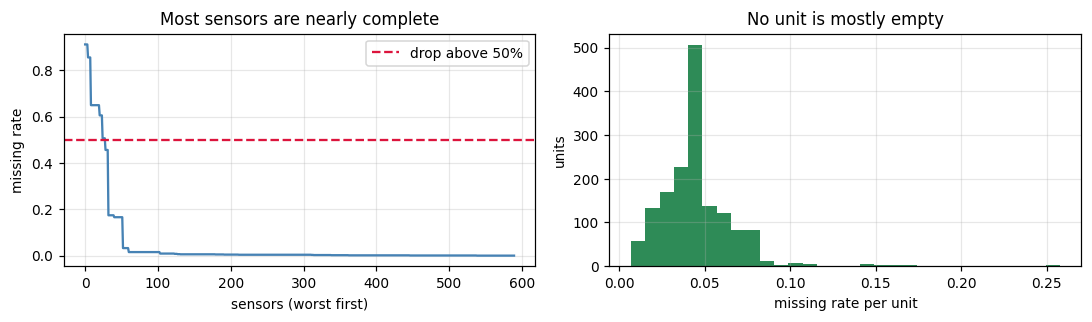

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(sorted(col_missing, reverse=True), color="steelblue")
ax[0].axhline(MAX_MISSING, ls="--", color="crimson", label=f"drop above {MAX_MISSING:.0%}")
ax[0].set_xlabel("sensors (worst first)"); ax[0].set_ylabel("missing rate")
ax[0].set_title("Most sensors are nearly complete"); ax[0].legend()

ax[1].hist(row_missing, bins=30, color="seagreen")
ax[1].set_xlabel("missing rate per unit"); ax[1].set_ylabel("units")
ax[1].set_title("No unit is mostly empty")
plt.tight_layout(); plt.show()

The picture is simple: a small group of sensors is broken or offline for most units, while the rest
are missing values only occasionally. So we drop the broken ones and fill in the rest. No unit
is missing enough to be worth deleting.

---
## 4. Split by time

The split happens **now**, before any statistic is calculated, so nothing from the test period can
influence the cleaning.

The split is by date rather than random, because in real use the model has to score today's unit
knowing only past units. A random split would let it train on future data and score better than it
deserves.

In [7]:
split_at = int(len(df) * (1 - TEST_FRACTION))
train = df.iloc[:split_at].copy()
test  = df.iloc[split_at:].copy()

print(f"train : {len(train):>5} units, {train.fail.sum():>3} failures ({train.fail.mean():.1%})  "
      f"up to {train.timestamp.max().date()}")
print(f"test  : {len(test):>5} units, {test.fail.sum():>3} failures ({test.fail.mean():.1%})  "
      f"from {test.timestamp.min().date()}")
print(f"\nno overlap in time: {train.timestamp.max() < test.timestamp.min()}")

train :  1253 units,  87 failures (6.9%)  up to 2008-10-02
test  :   314 units,  17 failures (5.4%)  from 2008-10-02

no overlap in time: True


---
## 5. Drop useless sensors

Three kinds of sensor carry no usable information:

- **Mostly missing** — more than half the readings are absent, so there is little to work with.
- **Constant** — the same value for every unit. Zero variation means zero information.
- **Duplicated** — two sensors that are essentially the same measurement (correlation above 0.9999).
  Keeping both adds nothing and confuses models that assume independent inputs.

All three are decided using the training data only.

In [8]:
tr_missing = train[SENSORS].isna().mean()

drop_missing  = tr_missing[tr_missing > MAX_MISSING].index.tolist()
drop_constant = [s for s in SENSORS
                 if s not in drop_missing and train[s].nunique(dropna=True) <= 1]

keep = [s for s in SENSORS if s not in drop_missing + drop_constant]

# Find duplicated sensors among the survivors
filled = train[keep].fillna(train[keep].median())
corr = filled.corr().abs().to_numpy(copy=True)
np.fill_diagonal(corr, 0)

drop_duplicate = set()
for i in range(len(keep)):
    for j in range(i + 1, len(keep)):
        if corr[i, j] > 0.9999 and keep[i] not in drop_duplicate:
            drop_duplicate.add(keep[j])

FEATURES = [s for s in keep if s not in drop_duplicate]

print(f"dropped - mostly missing : {len(drop_missing)}")
print(f"dropped - constant       : {len(drop_constant)}")
print(f"dropped - duplicated     : {len(drop_duplicate)}")
print(f"\nsensors kept: {len(FEATURES)} out of {len(SENSORS)}")

dropped - mostly missing : 24
dropped - constant       : 122
dropped - duplicated     : 8

sensors kept: 436 out of 590


---
## 6. Fill in missing values

**Median, not mean.** Sensor readings here have long tails, so the mean sits far from a typical
value. The median is not affected by extremes.

**Medians come from the training set.** They are applied unchanged to the test set. This is what
rule 1 looks like in practice.

**Flags come first.** For sensors missing more than 2% of the time, we add a `_isna` column
recording that the value was missing before filling it in. A sensor going offline can itself be a
sign of a problem, and once the gap is filled that information is gone.

In [9]:
flag_cols = [s for s in FEATURES if tr_missing[s] > FLAG_THRESHOLD]
medians = train[FEATURES].median()

def fill_missing(data):
    out = data.copy()
    for s in flag_cols:
        out[f"{s}_isna"] = out[s].isna().astype("int8")
    out[FEATURES] = out[FEATURES].fillna(medians)
    return out

train = fill_missing(train)
test  = fill_missing(test)

print(f"missing-value flags added : {len(flag_cols)}")
print(f"missing values left       : train {train[FEATURES].isna().sum().sum()}, "
      f"test {test[FEATURES].isna().sum().sum()}")

missing-value flags added : 28
missing values left       : train 0, test 0


---
## 7. Handle outliers

Extreme readings distort models, but deleting the units that have them would be a serious mistake
here. Failures are rare, and a sensor reading far outside its normal range is exactly what we would
expect before a defect. Removing those units removes the signal.

So values are **clipped** to the 0.5% and 99.5% points of the training data. Every unit is kept, and
no reading can pull a model too far.

In [10]:
low  = train[FEATURES].quantile(CLIP_LOW)
high = train[FEATURES].quantile(CLIP_HIGH)

# Leave a sensor alone if its two limits are the same (no spread to clip)
no_spread = high <= low
low  = low.mask(no_spread, -np.inf)
high = high.mask(no_spread,  np.inf)

before = train[FEATURES].copy()
train[FEATURES] = train[FEATURES].clip(low, high, axis=1)
test[FEATURES]  = test[FEATURES].clip(low, high, axis=1)

changed = (before.to_numpy() != train[FEATURES].to_numpy()).sum()
print(f"values clipped in train : {changed:,} ({changed / before.size:.1%} of all readings)")
print(f"units removed           : 0")
print(f"failures still present  : {train.fail.sum() + test.fail.sum()}")

values clipped in train : 5,382 (1.0% of all readings)
units removed           : 0
failures still present  : 104


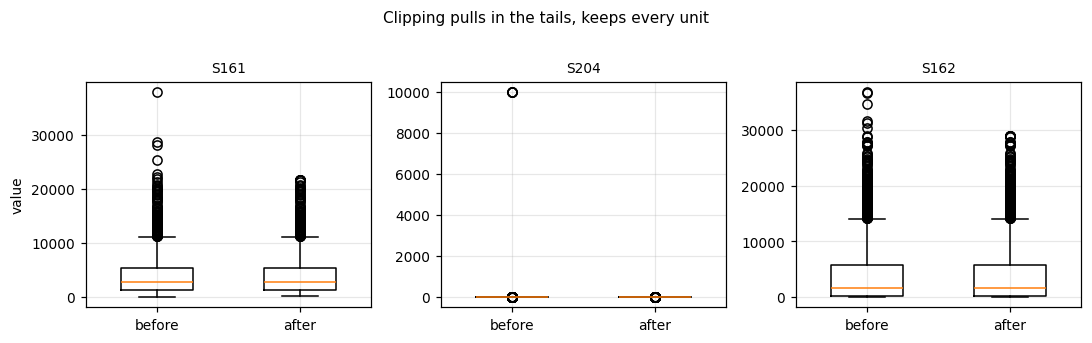

In [11]:
# Check the effect on a few of the most skewed sensors
worst = (before.max() - before.quantile(0.99)).nlargest(3).index

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, s in zip(axes, worst):
    ax.boxplot([before[s], train[s]], tick_labels=["before", "after"], widths=0.5)
    ax.set_title(s, fontsize=9)
axes[0].set_ylabel("value")
plt.suptitle("Clipping pulls in the tails, keeps every unit", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

---
## 8. Final checks

Confirm the cleaned data actually has the properties we claimed, rather than assuming it.

In [12]:
MODEL_COLS = FEATURES + [f"{s}_isna" for s in flag_cols]

checks = {
    "no missing values":          train[MODEL_COLS].isna().sum().sum() == 0
                                  and test[MODEL_COLS].isna().sum().sum() == 0,
    "no constant sensors":        (train[FEATURES].nunique() <= 1).sum() == 0,
    "same columns in both sets":  list(train[MODEL_COLS]) == list(test[MODEL_COLS]),
    "no units lost":              len(train) + len(test) == len(df),
    "train comes before test":    train.timestamp.max() < test.timestamp.min(),
}
for name, ok in checks.items():
    print(f"  {'OK  ' if ok else 'FAIL'}  {name}")
assert all(checks.values())

print(f"\nfinal dataset: {len(MODEL_COLS)} columns "
      f"({len(FEATURES)} sensors + {len(flag_cols)} flags)")

  OK    no missing values
  OK    no constant sensors
  OK    same columns in both sets
  OK    no units lost
  OK    train comes before test

final dataset: 464 columns (436 sensors + 28 flags)


---
## 9. Save

In [13]:
cols = ["timestamp", "fail"] + MODEL_COLS
train[cols].to_csv(OUT / "secom_train_clean.csv", index=False)
test[cols].to_csv(OUT / "secom_test_clean.csv", index=False)

for f in ["secom_train_clean.csv", "secom_test_clean.csv"]:
    print(f"saved {f}  ({(OUT / f).stat().st_size / 1e6:.1f} MB)")

saved secom_train_clean.csv  (4.0 MB)
saved secom_test_clean.csv  (1.0 MB)


---
## Summary

| Step | Result |
|---|---|
| Started with | 590 sensors, 1,567 units |
| Dropped mostly-missing sensors | −24 |
| Dropped constant sensors | −122 |
| Dropped duplicated sensors | −8 |
| Filled remaining gaps | median from training set |
| Added missing-value flags | +28 |
| Clipped extreme values | no units removed |
| **Final** | **464 columns**, 1,253 train + 314 test units |

**Not done here, on purpose:**

- **Scaling** — belongs in the modelling pipeline so it can be fitted separately for each
  cross-validation fold.
- **Feature selection** — uses the labels, so doing it now would leak information into validation.
- **Balancing the classes (SMOTE etc.)** — only ever applied to training folds, never to a saved
  dataset.

**Next:** exploratory analysis on the training set — which sensors relate to failure, how they
relate to each other, and how they behave over time.

**Worth remembering:** the test set contains only 17 failures. That is a small number to judge a
model on, so use time-ordered cross-validation on the training set for choosing models, and save the
test set for one final check.